# Stress Detection from EEG Signals (SAM-40)

This notebook builds a pipeline that predicts **stress** from raw EEG recordings
(SAM-40 dataset), and explains *why* the models make their predictions using **SHAP**.

**Pipeline**
1. Load trial labels
2. Preprocess raw EEG (filter, ICA, epoching)
3. Build the full epoched dataset
4. Subject-level train/test split (no subject leakage)
5. Binarize the stress target
6. Extract band-power features
7. Scale features
8. Train & evaluate several classifiers
9. Compare models
10. **Explain the best model with SHAP**


## 1. Setup

All imports and configuration constants live here so the rest of the notebook stays clean.

In [2]:
# --- Standard library ---
from pathlib import Path

# --- Data handling ---
import numpy as np
import pandas as pd
from scipy.io import loadmat

# --- EEG processing ---
import mne
from mne.time_frequency import psd_array_welch

# --- Modeling ---
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

# --- Evaluation ---
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

# --- Statistics ---
from itertools import combinations
from scipy import stats
from statsmodels.stats.multitest import multipletests

# --- Explainability ---
import shap

# --- Plotting ---
import matplotlib.pyplot as plt

mne.set_log_level("ERROR")

/Users/parsa/Desktop/projects/github/pxsa/EEG-stress-xai/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# --- Paths ---
DATA_FOLDER = Path("../Data/")
RAW_DATA_FOLDER = Path("../Data/raw_data/")
PROCESSED_FOLDER = Path("../Data/processed/")
PROCESSED_FOLDER.mkdir(parents=True, exist_ok=True)

# --- EEG acquisition / filtering parameters ---
SFREQ = 128          # Hz
N_CHANNELS = 32
LOW_FREQ = 0.5       # Hz, high-pass cutoff
HIGH_FREQ = 45       # Hz, low-pass cutoff

# --- Epoching ---
EPOCH_DURATION = 2.0  # seconds
EPOCH_OVERLAP = 1.0   # seconds

# --- Frequency bands used for feature extraction ---
BANDS = {
    "delta": (1, 4),
    "theta": (4, 8),
    "alpha": (8, 13),
    "beta": (13, 30),
    "gamma": (30, 45),
}

# --- Reproducibility ---
RANDOM_STATE = 42

# --- Target definition ---
STRESS_BINARY_THRESHOLD = 4  # stress_level >= 4 -> "stressed" 

## 2. Load Trial Labels

`preprocessed_data.csv` (built in `preprocessing.ipynb`) maps every raw `.mat` file to its
subject, trial, task ("kind") and self-reported `stress_level`.

In [4]:
data_labels = pd.read_csv(DATA_FOLDER / "preprocessed_data.csv")

print("Shape:", data_labels.shape)
data_labels.head()

Shape: (480, 5)


,subject,trial,kind,file_name,stress_level
0,1,1,Relax,Relax_sub_1_trial1.mat,0
1,1,1,Mirror,Mirror_image_sub_1_trial1.mat,3
2,1,1,Arithmetic,Arithmetic_sub_1_trial1.mat,6
3,1,1,Stroop,Stroop_sub_1_trial1.mat,3
4,1,2,Mirror,Mirror_image_sub_1_trial2.mat,5


In [5]:
data_labels["kind"].value_counts()

kind
Relax         120
Mirror        120
Arithmetic    120
Stroop        120
Name: count, dtype: int64

In [6]:
# The "Relax" condition has no comparable stress task, so it is dropped.
stress_df = data_labels[data_labels["kind"] != "Relax"].copy()
stress_df["kind"].value_counts()

kind
Mirror        120
Arithmetic    120
Stroop        120
Name: count, dtype: int64

## 3. EEG Preprocessing Pipeline

For each `.mat` recording:
1. Load the raw 32-channel array (`32 x 3200` samples).
2. Band-pass filter (`0.5–45 Hz`).
3. Remove artifacts with ICA (Picard algorithm).
4. Cut the continuous signal into fixed-length, overlapping epochs (2s, 1s overlap).
5. Attach the trial's metadata (subject, trial, kind, stress_level) to every resulting epoch.

In [7]:
def process_file(filepath, labels_df=data_labels):
    """Load, clean, and epoch a single raw EEG recording.

    Parameters
    ----------
    filepath : str or Path
        Path to a SAM-40 ``.mat`` recording.
    labels_df : pd.DataFrame
        Table used to look up metadata for this file (must contain a
        ``file_name`` column).

    Returns
    -------
    X : np.ndarray, shape (n_epochs, n_channels, n_samples)
        Cleaned, epoched EEG data.
    metadata : pd.DataFrame, shape (n_epochs, ...)
        One metadata row per epoch (subject, trial, kind, stress_level).
    """
    mat = loadmat(filepath)
    data = mat["Data"]  # (32 channels, 3200 samples)

    ch_names = [f"EEG{i:03d}" for i in range(1, N_CHANNELS + 1)]
    info = mne.create_info(ch_names=ch_names, sfreq=SFREQ, ch_types="eeg")
    raw = mne.io.RawArray(data, info, verbose=False)

    # Band-pass filter
    raw_filtered = raw.copy()
    raw_filtered.filter(l_freq=LOW_FREQ, h_freq=HIGH_FREQ, verbose=False)

    # Artifact removal via ICA
    ica = mne.preprocessing.ICA(
        n_components=15,
        random_state=RANDOM_STATE,
        max_iter=1000,
        method="picard",
        fit_params={"tol": 0.01},
    )
    ica.fit(raw_filtered, verbose=False)

    raw_clean = raw_filtered.copy()
    ica.apply(raw_clean, verbose=False)

    # Fixed-length epoching
    epochs = mne.make_fixed_length_epochs(
        raw_clean,
        duration=EPOCH_DURATION,
        overlap=EPOCH_OVERLAP,
        preload=True,
        verbose=False,
    )
    X = epochs.get_data()

    # Attach metadata (repeated once per epoch)
    file_name = str(filepath).split("/")[-1]
    n_epochs = X.shape[0]
    metadata = labels_df[labels_df["file_name"] == file_name][
        ["subject", "trial", "kind", "stress_level"]
    ]
    metadata = pd.concat([metadata] * n_epochs, ignore_index=True)

    return X, metadata

In [8]:
# Sanity check on a single file
sample_filepath = RAW_DATA_FOLDER / "Mirror_image_sub_1_trial1.mat"
X_sample, metadata_sample = process_file(sample_filepath)

print("X_sample:", X_sample.shape)
metadata_sample.head()

X_sample: (24, 32, 256)


,subject,trial,kind,stress_level
0,1,1,Mirror,3
1,1,1,Mirror,3
2,1,1,Mirror,3
3,1,1,Mirror,3
4,1,1,Mirror,3


## 4. Build the Full Dataset

Run `process_file` over every labeled trial and concatenate the results.

In [9]:
all_X = []
all_metadata = []

for _, row in data_labels.iterrows():
    file_path = RAW_DATA_FOLDER / row["file_name"]
    X_trial, metadata_trial = process_file(file_path)
    all_X.append(X_trial)
    all_metadata.append(metadata_trial)

X_full = np.concatenate(all_X, axis=0)
metadata_full = pd.concat(all_metadata, ignore_index=True)

print("X_full:", X_full.shape)
print("metadata_full:", metadata_full.shape)
metadata_full.head()

X_full: (11520, 32, 256)
metadata_full: (11520, 4)


,subject,trial,kind,stress_level
0,1,1,Relax,0
1,1,1,Relax,0
2,1,1,Relax,0
3,1,1,Relax,0
4,1,1,Relax,0


In [10]:
metadata_full["stress_level"].value_counts().sort_index()

stress_level
0     2880
1      456
2      600
3     1392
4     1296
5     1848
6     1368
7      768
8      576
9      240
10      96
Name: count, dtype: int64

In [11]:
metadata_full.groupby("kind")["stress_level"].agg(["count", "mean", "min", "max"])

,count,mean,min,max
kind,,,,
Arithmetic,2880,5.441667,1,10
Mirror,2880,4.941667,1,9
Relax,2880,0.000000,0,0
Stroop,2880,4.050000,1,9


## 5. Save Processed Data

Cache the epoched array and metadata so preprocessing doesn't need to be repeated.

In [12]:
np.save(PROCESSED_FOLDER / "X.npy", X_full)
metadata_full.to_csv(PROCESSED_FOLDER / "metadata.csv", index=False)

## 6. Subject-Level Train/Test Split

Epochs from the same subject are correlated, so splitting must happen **by subject**
(not by epoch) to avoid leaking subject-specific signal between train and test sets.

In [13]:
subjects = metadata_full["subject"].unique()
print("Number of subjects:", len(subjects))
print("Subjects:", subjects)

Number of subjects: 40
Subjects: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40]


In [14]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)

train_idx, test_idx = next(
    gss.split(X_full, groups=metadata_full["subject"])
)

X_train = X_full[train_idx]
X_test = X_full[test_idx]

metadata_train = metadata_full.iloc[train_idx].reset_index(drop=True)
metadata_test = metadata_full.iloc[test_idx].reset_index(drop=True)

In [15]:
train_subjects = set(metadata_train["subject"])
test_subjects = set(metadata_test["subject"])

print("Train subjects:", sorted(train_subjects))
print("Test subjects :", sorted(test_subjects))
print("Number of train subjects:", len(train_subjects))
print("Number of test subjects :", len(test_subjects))
print("Overlap (should be empty):", train_subjects.intersection(test_subjects))

Train subjects: [1, 2, 3, 4, 6, 7, 8, 9, 10, 11, 12, 14, 15, 18, 19, 21, 22, 23, 24, 25, 26, 29, 30, 31, 32, 33, 34, 35, 36, 37, 39, 40]
Test subjects : [5, 13, 16, 17, 20, 27, 28, 38]
Number of train subjects: 32
Number of test subjects : 8
Overlap (should be empty): set()


In [16]:
print("X_train:", X_train.shape, " metadata_train:", metadata_train.shape)
print("X_test :", X_test.shape, " metadata_test :", metadata_test.shape)

X_train: (9216, 32, 256)  metadata_train: (9216, 4)
X_test : (2304, 32, 256)  metadata_test : (2304, 4)


## 7. Make the Target Binary

`stress_level >= STRESS_BINARY_THRESHOLD` (4) is treated as "stressed" (`1`), everything below as "not stressed" (`0`).

In [17]:
metadata_train["stress_binary"] = (
    metadata_train["stress_level"] >= STRESS_BINARY_THRESHOLD
).astype(int)
metadata_test["stress_binary"] = (
    metadata_test["stress_level"] >= STRESS_BINARY_THRESHOLD
).astype(int)

y_train = metadata_train["stress_binary"].to_numpy()
y_test = metadata_test["stress_binary"].to_numpy()

In [18]:
print("Train class balance:")
print(metadata_train["stress_binary"].value_counts(normalize=True))

print("\nTest class balance:")
print(metadata_test["stress_binary"].value_counts(normalize=True))

Train class balance:
stress_binary
1    0.53125
0    0.46875
Name: proportion, dtype: float64

Test class balance:
stress_binary
1    0.5625
0    0.4375
Name: proportion, dtype: float64


In [19]:
metadata_train.groupby("stress_binary")["stress_level"].agg(["count", "min", "max", "mean"])

,count,min,max,mean
stress_binary,,,,
0,4320,0,3,1.100000
1,4896,4,10,5.661765


## 8. Exploratory Data Analysis: Stress & Task Patterns

Before extracting EEG features, it's worth looking at how the self-reported `stress_level`
label actually behaves — across tasks and across subjects. This section works on
`metadata_full` (label-level data only), so it doesn't need the band-power features yet.

> **Note on "Relax" trials:** earlier, `stress_df` was created to drop the `"Relax"`
> condition, but `metadata_full`/`X_full` were built from the *unfiltered* `data_labels`,
> so Relax epochs (which always get `stress_level = 0` from `extract_stress_level`) are
> still present in the modeling data below. That's worth deciding on deliberately — the
> plots here make the effect visible.

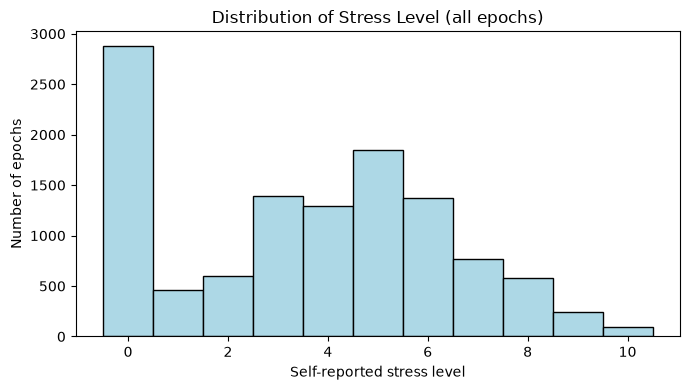

In [20]:
metadata_full["stress_binary"] = (
    metadata_full["stress_level"] >= STRESS_BINARY_THRESHOLD
).astype(int)  # descriptive only — the modeling target is fit separately on train/test

fig, ax = plt.subplots(figsize=(7, 4))
max_level = int(metadata_full["stress_level"].max())
metadata_full["stress_level"].plot.hist(
    bins=range(0, max_level + 2), ax=ax, color='lightblue', edgecolor="black", align="left"
)
ax.set_xlabel("Self-reported stress level")
ax.set_ylabel("Number of epochs")
ax.set_title("Distribution of Stress Level (all epochs)")
plt.tight_layout()
plt.show()

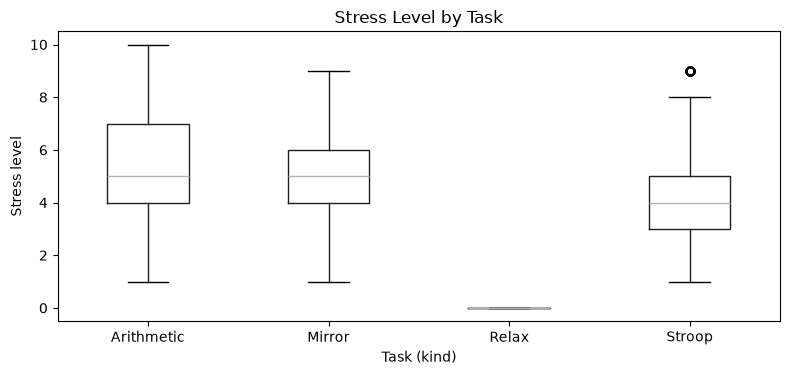

In [23]:
fig, ax = plt.subplots(figsize=(8, 4))
metadata_full.boxplot(column="stress_level", by="kind", ax=ax, grid=False)
ax.set_title("Stress Level by Task")
ax.set_xlabel("Task (kind)")
ax.set_ylabel("Stress level")
plt.suptitle("")
plt.tight_layout()
plt.show()

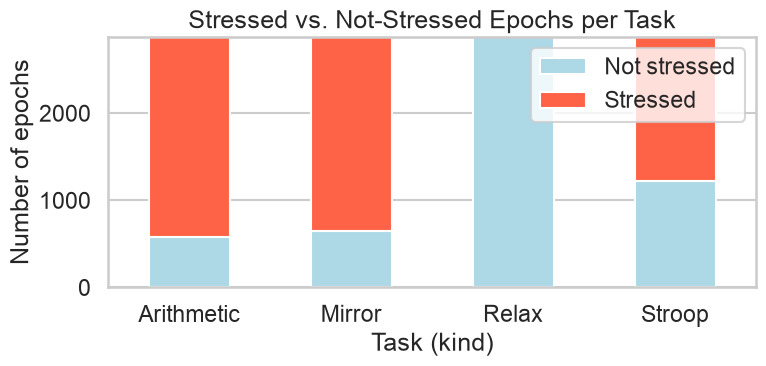

In [24]:
counts = metadata_full.groupby(["kind", "stress_binary"]).size().unstack(fill_value=0)
counts.columns = ["Not stressed", "Stressed"]

ax = counts.plot.bar(stacked=True, figsize=(8, 4), color=["lightblue", "tomato"])
ax.set_xlabel("Task (kind)")
ax.set_ylabel("Number of epochs")
ax.set_title("Stressed vs. Not-Stressed Epochs per Task")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

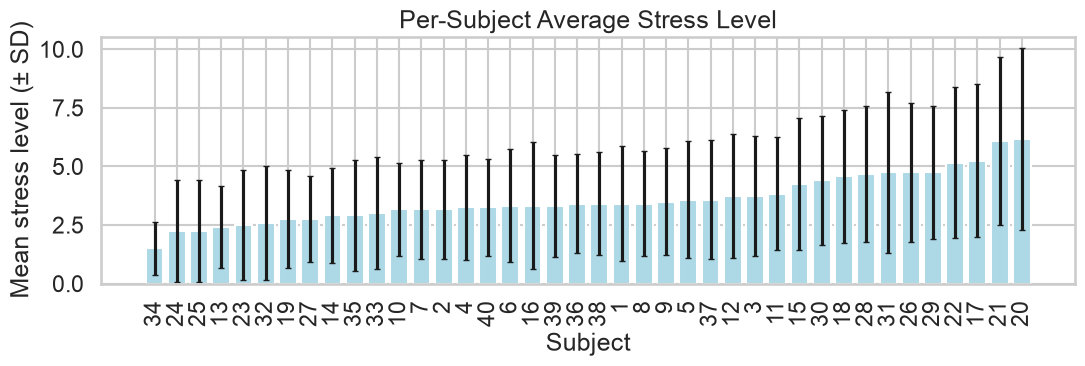

In [25]:
subject_stress = (
    metadata_full.groupby("subject")["stress_level"]
    .agg(["mean", "std", "count"])
    .sort_values("mean")
)

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(
    subject_stress.index.astype(str),
    subject_stress["mean"],
    yerr=subject_stress["std"],
    capsize=2,
    color='lightblue'
)
ax.set_xlabel("Subject")
ax.set_ylabel("Mean stress level (± SD)")
ax.set_title("Per-Subject Average Stress Level")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

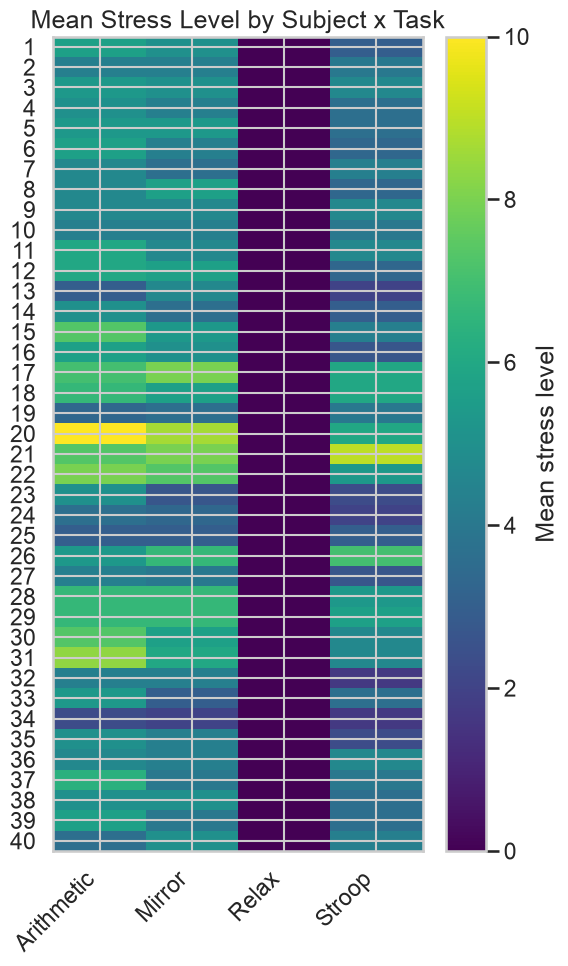

In [26]:
pivot = metadata_full.pivot_table(
    index="subject", columns="kind", values="stress_level", aggfunc="mean"
)

fig, ax = plt.subplots(figsize=(6, 10))
im = ax.imshow(pivot.values, aspect="auto", cmap="viridis")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right")
ax.set_title("Mean Stress Level by Subject x Task")
fig.colorbar(im, ax=ax, label="Mean stress level")
plt.tight_layout()
plt.show()

### 8.1 Hypothesis Test: Does Task Type Affect Reported Stress?

**H₀:** the mean/median self-reported stress level is the same across the three stress
tasks (Arithmetic, Mirror, Stroop).
**H₁:** at least one task differs.

Self-report scores are bounded and often not normally distributed, so both a normality
check (Shapiro-Wilk) and a variance-homogeneity check (Levene) are run first to decide
whether the parametric ANOVA assumptions hold — the non-parametric **Kruskal-Wallis**
test is reported as the primary result regardless, since it doesn't rely on those
assumptions.

In [28]:
task_df = metadata_full[metadata_full["kind"] != "Relax"]
task_names = sorted(task_df["kind"].unique())
groups = [task_df.loc[task_df["kind"] == k, "stress_level"].values for k in task_names]

rng = np.random.RandomState(RANDOM_STATE)
print("Normality check (Shapiro-Wilk, subsampled to <=5000):")
for name, g in zip(task_names, groups):
    sample = g if len(g) <= 5000 else rng.choice(g, 5000, replace=False)
    stat, p = stats.shapiro(sample)
    verdict = "looks normal" if p > 0.05 else "NOT normal"
    print(f"  {name:<12} p={p:.4g}  ({verdict} at alpha=0.05)")

levene_stat, levene_p = stats.levene(*groups)
print(f"\nLevene's test for equal variances: stat={levene_stat:.3f}, p={levene_p:.4g}")

kw_stat, kw_p = stats.kruskal(*groups)
print(f"\nKruskal-Wallis (primary, non-parametric): H={kw_stat:.3f}, p={kw_p:.4g}")

anova_stat, anova_p = stats.f_oneway(*groups)
print(f"One-way ANOVA (reference, parametric):    F={anova_stat:.3f}, p={anova_p:.4g}")

Normality check (Shapiro-Wilk, subsampled to <=5000):
  Arithmetic   p=2.83e-25  (NOT normal at alpha=0.05)
  Mirror       p=5.275e-25  (NOT normal at alpha=0.05)
  Stroop       p=6.294e-30  (NOT normal at alpha=0.05)

Levene's test for equal variances: stat=9.607, p=6.801e-05

Kruskal-Wallis (primary, non-parametric): H=664.735, p=4.515e-145
One-way ANOVA (reference, parametric):    F=383.275, p=3.33e-160


In [29]:
# Post-hoc pairwise comparisons, Bonferroni-corrected for the 3 pairwise tests.
alpha = 0.05
pairs = list(combinations(task_names, 2))
corrected_alpha = alpha / len(pairs)

print(f"Post-hoc pairwise Mann-Whitney U tests (Bonferroni-corrected alpha={corrected_alpha:.4f}):")
for a, b in pairs:
    ga = task_df.loc[task_df["kind"] == a, "stress_level"]
    gb = task_df.loc[task_df["kind"] == b, "stress_level"]
    stat, p = stats.mannwhitneyu(ga, gb, alternative="two-sided")
    verdict = "significant" if p < corrected_alpha else "not significant"
    print(f"  {a} vs {b:<10} U={stat:.1f}, p={p:.4g}  -> {verdict}")

Post-hoc pairwise Mann-Whitney U tests (Bonferroni-corrected alpha=0.0167):
  Arithmetic vs Mirror     U=4680576.0, p=1.224e-17  -> significant
  Arithmetic vs Stroop     U=5704416.0, p=1.518e-137  -> significant
  Mirror vs Stroop     U=5229504.0, p=1.494e-67  -> significant


## 9. Feature Extraction: Band Power

For each epoch and channel, compute average PSD (Welch's method) inside each of the
5 canonical EEG bands (`delta, theta, alpha, beta, gamma`). This turns each epoch
`(32 channels, 256 samples)` into a flat feature vector of length `32 * 5 = 160`.

In [30]:
def extract_band_power(X, sfreq=SFREQ, bands=BANDS):
    """Compute per-channel, per-band average power.

    Parameters
    ----------
    X : np.ndarray, shape (n_epochs, n_channels, n_samples)

    Returns
    -------
    features : np.ndarray, shape (n_epochs, n_channels * n_bands)
        Feature order is channel-major: for each channel, the bands appear
        in the order given by ``bands`` (delta, theta, alpha, beta, gamma).
    """
    psds, freqs = psd_array_welch(
        X, sfreq=sfreq, fmin=1, fmax=45, n_fft=256, verbose=False
    )
    # psds: (epochs, channels, frequencies)

    band_powers = []
    for band_name, (low, high) in bands.items():
        freq_mask = (freqs >= low) & (freqs < high)
        band_power = psds[:, :, freq_mask].mean(axis=2)  # (epochs, channels)
        band_powers.append(band_power)

    # (epochs, channels, bands) -> (epochs, channels * bands)
    features = np.stack(band_powers, axis=2)
    n_epochs = features.shape[0]
    features = features.reshape(n_epochs, -1)
    return features


def get_feature_names(n_channels=N_CHANNELS, bands=BANDS):
    """Feature names matching the flatten order used in ``extract_band_power``."""
    ch_names = [f"EEG{i:03d}" for i in range(1, n_channels + 1)]
    return [f"{ch}_{band}" for ch in ch_names for band in bands]

In [31]:
X_train_features = extract_band_power(X_train)
X_test_features = extract_band_power(X_test)
feature_names = get_feature_names()

print("X_train_features:", X_train_features.shape)
print("X_test_features :", X_test_features.shape)
print("Number of feature names:", len(feature_names))

X_train_features: (9216, 160)
X_test_features : (2304, 160)
Number of feature names: 160


## 10. Standardize Features

Some models (Logistic Regression, SVM, KNN) are sensitive to feature scale.
The scaler is **fit on train only** and applied to both splits.

In [32]:
print("Raw feature range:", X_train_features.min(), "to", X_train_features.max())

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled = scaler.transform(X_test_features)

print("Scaled train mean/std:", X_train_scaled.mean(), X_train_scaled.std())

Raw feature range: 0.03759680106086731 to 35046.755428613214
Scaled train mean/std: 1.3322676295501878e-16 1.0


## 11. Statistical Tests: EEG Band Power vs. Stress

Does band power actually differ between "stressed" and "not stressed" epochs, or is any
model performance just picking up noise? This section runs formal hypothesis tests on
the **training set only** (test set stays untouched) at two levels:

- **Band level (11.2):** average power per band across all 32 channels — one test per
  band (5 tests total).
- **Feature level (11.3):** every individual channel x band feature (160 tests), with
  multiple-comparison correction.

### 11.1 Assumption Checks

EEG power is typically right-skewed, so normality shouldn't be assumed — this is checked
directly rather than assumed, which determines whether the non-parametric Mann-Whitney U
test or the parametric t-test is the more appropriate primary test.

In [33]:
band_names = list(BANDS.keys())
n_bands = len(band_names)

# feature_names / X_train_features are channel-major: channel0's 5 bands, then channel1's, ...
# reshape back to (n_epochs, n_channels, n_bands) and average across channels.
X_train_band_avg = X_train_features.reshape(-1, N_CHANNELS, n_bands).mean(axis=1)
band_avg_df = pd.DataFrame(X_train_band_avg, columns=band_names)
band_avg_df["stress_binary"] = y_train

rng = np.random.RandomState(RANDOM_STATE)
print("Normality check (Shapiro-Wilk, subsampled to <=5000 per group):")
for band in band_names:
    for cls, label in [(0, "not stressed"), (1, "stressed")]:
        vals = band_avg_df.loc[band_avg_df["stress_binary"] == cls, band].values
        sample = vals if len(vals) <= 5000 else rng.choice(vals, 5000, replace=False)
        stat, p = stats.shapiro(sample)
        verdict = "looks normal" if p > 0.05 else "NOT normal"
        print(f"  {band:<6} | {label:<12} p={p:.4g}  ({verdict})")

    lev_stat, lev_p = stats.levene(
        band_avg_df.loc[band_avg_df["stress_binary"] == 0, band],
        band_avg_df.loc[band_avg_df["stress_binary"] == 1, band],
    )
    print(f"  {band:<6} | Levene's test for equal variances: p={lev_p:.4g}\n")

Normality check (Shapiro-Wilk, subsampled to <=5000 per group):
  delta  | not stressed p=4.192e-83  (NOT normal)
  delta  | stressed     p=9.583e-94  (NOT normal)
  delta  | Levene's test for equal variances: p=0.0003274

  theta  | not stressed p=1.468e-74  (NOT normal)
  theta  | stressed     p=9.639e-72  (NOT normal)
  theta  | Levene's test for equal variances: p=6.926e-10

  alpha  | not stressed p=5.603e-70  (NOT normal)
  alpha  | stressed     p=1.229e-60  (NOT normal)
  alpha  | Levene's test for equal variances: p=4.891e-18

  beta   | not stressed p=2.367e-53  (NOT normal)
  beta   | stressed     p=3.475e-58  (NOT normal)
  beta   | Levene's test for equal variances: p=0.5815

  gamma  | not stressed p=8.468e-64  (NOT normal)
  gamma  | stressed     p=9.372e-69  (NOT normal)
  gamma  | Levene's test for equal variances: p=0.4249



### 11.2 Band-Level Test: Stressed vs. Not-Stressed

Given the non-normality expected above, **Mann-Whitney U** is the primary test; **Welch's
t-test** (which doesn't assume equal variances) is reported alongside it for reference.
**Cohen's d** quantifies effect size, since statistical significance alone doesn't say
how large the difference is.

In [34]:
def cohens_d(x, y):
    """Standardized mean difference (pooled SD) between two 1-D samples."""
    nx, ny = len(x), len(y)
    pooled_std = np.sqrt(
        ((nx - 1) * np.var(x, ddof=1) + (ny - 1) * np.var(y, ddof=1)) / (nx + ny - 2)
    )
    return (np.mean(x) - np.mean(y)) / pooled_std


band_test_results = []
for band in band_names:
    not_stressed = band_avg_df.loc[band_avg_df["stress_binary"] == 0, band]
    stressed = band_avg_df.loc[band_avg_df["stress_binary"] == 1, band]

    u_stat, u_p = stats.mannwhitneyu(stressed, not_stressed, alternative="two-sided")
    t_stat, t_p = stats.ttest_ind(stressed, not_stressed, equal_var=False)  # Welch, reference
    d = cohens_d(stressed, not_stressed)

    band_test_results.append({
        "band": band,
        "mean_not_stressed": not_stressed.mean(),
        "mean_stressed": stressed.mean(),
        "mannwhitney_p": u_p,
        "welch_t_p": t_p,
        "cohens_d": d,
    })

band_test_df = pd.DataFrame(band_test_results).set_index("band")
band_test_df

,mean_not_stressed,mean_stressed,mannwhitney_p,welch_t_p,cohens_d
band,,,,,
delta,93.113156,69.546096,6.537524e-15,9.129862e-05,-0.079073
theta,10.122692,8.688868,1.321835e-09,1.329579e-10,-0.136772
alpha,3.973483,3.393013,5.056518e-15,2.848242e-22,-0.208738
beta,1.654803,1.621070,9.227544e-03,9.394662e-02,-0.034916
gamma,1.081083,1.121190,1.371278e-03,4.958455e-02,0.040818


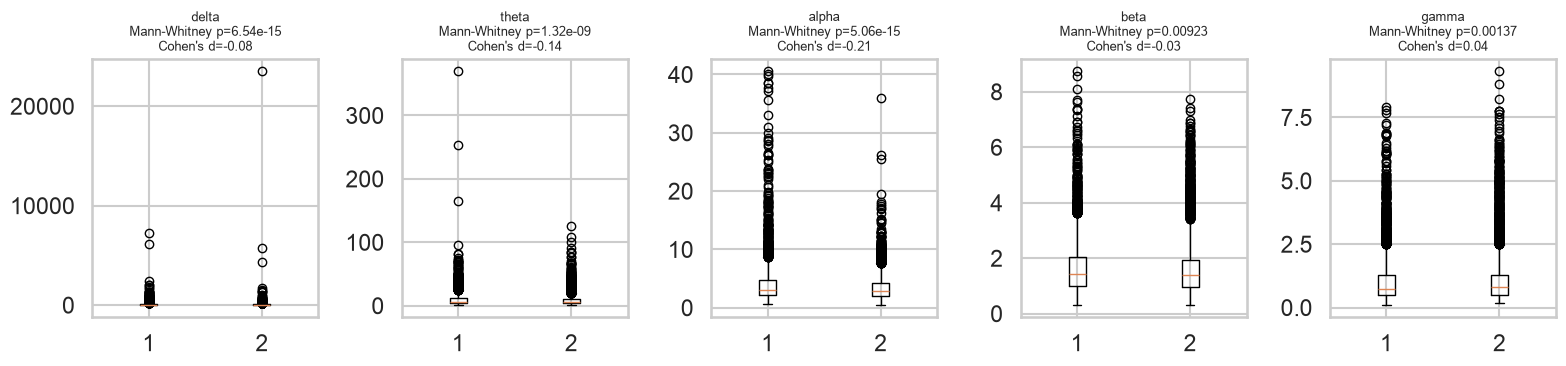

In [35]:
fig, axes = plt.subplots(1, n_bands, figsize=(3.2 * n_bands, 4), sharey=False)
for ax, band in zip(axes, band_names):
    data_to_plot = [
        band_avg_df.loc[band_avg_df["stress_binary"] == 0, band],
        band_avg_df.loc[band_avg_df["stress_binary"] == 1, band],
    ]
    ax.boxplot(data_to_plot, label=["Not\nstressed", "Stressed"])
    p = band_test_df.loc[band, "mannwhitney_p"]
    d = band_test_df.loc[band, "cohens_d"]
    ax.set_title(f"{band}\nMann-Whitney p={p:.3g}\nCohen's d={d:.2f}", fontsize=9)

plt.tight_layout()
plt.show()

### 11.3 Feature-Level Test: All 160 Channel x Band Features

Running one test per feature means 160 comparisons, which inflates the false-positive
rate — **Benjamini-Hochberg FDR correction** controls for that while staying less
conservative than Bonferroni.

In [36]:
feature_pvals, feature_effects = [], []
for i, fname in enumerate(feature_names):
    x0 = X_train_features[y_train == 0, i]
    x1 = X_train_features[y_train == 1, i]
    _, p = stats.mannwhitneyu(x1, x0, alternative="two-sided")
    feature_pvals.append(p)
    feature_effects.append(cohens_d(x1, x0))

feature_stats_df = pd.DataFrame({
    "feature": feature_names,
    "p_value": feature_pvals,
    "cohens_d": feature_effects,
})

reject, p_fdr, _, _ = multipletests(feature_stats_df["p_value"], alpha=0.05, method="fdr_bh")
feature_stats_df["p_value_fdr"] = p_fdr
feature_stats_df["significant_fdr"] = reject

n_sig = int(feature_stats_df["significant_fdr"].sum())
print(f"{n_sig} / {len(feature_names)} features significant after FDR correction (alpha=0.05)")

feature_stats_df.sort_values("p_value_fdr").head(15)

117 / 160 features significant after FDR correction (alpha=0.05)


,feature,p_value,cohens_d,p_value_fdr,significant_fdr
159,EEG032_gamma,2.970425e-25,0.205555,4.752680e-23,True
107,EEG022_alpha,6.434402e-22,-0.250312,5.147522e-20,True
102,EEG021_alpha,2.133742e-21,-0.237636,1.137996e-19,True
10,EEG003_delta,6.893303e-20,-0.177914,2.757321e-18,True
112,EEG023_alpha,1.656768e-18,-0.249312,5.301657e-17,True
5,EEG002_delta,2.485791e-18,-0.179343,6.628776e-17,True
15,EEG004_delta,1.357333e-17,-0.144297,3.102476e-16,True
142,EEG029_alpha,5.066140e-17,-0.188231,1.013228e-15,True
140,EEG029_delta,6.487936e-17,-0.051308,1.153411e-15,True
7,EEG002_alpha,1.157285e-16,-0.135410,1.851656e-15,True


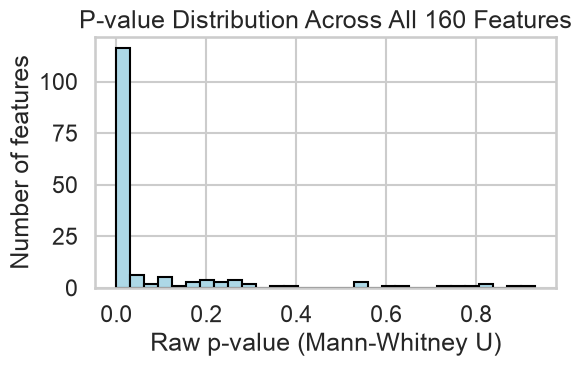

In [38]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(feature_stats_df["p_value"], bins=30, edgecolor="black", color='lightblue')
ax.set_xlabel("Raw p-value (Mann-Whitney U)")
ax.set_ylabel("Number of features")
ax.set_title("P-value Distribution Across All 160 Features")
plt.tight_layout()
plt.show()

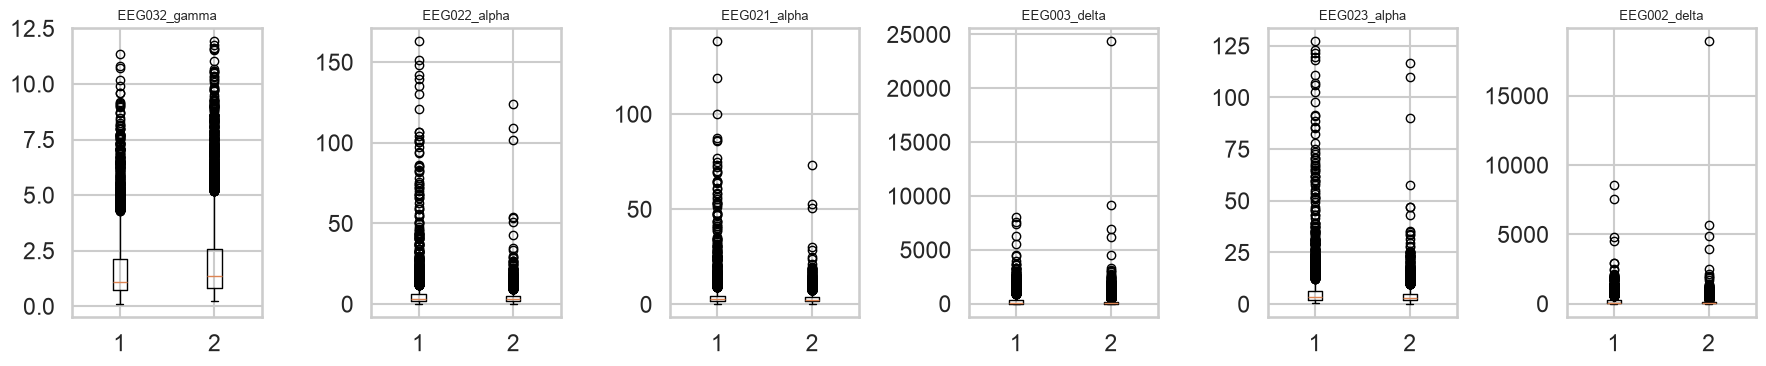

In [39]:
top_features = feature_stats_df.sort_values("p_value_fdr").head(6)["feature"].tolist()

fig, axes = plt.subplots(1, len(top_features), figsize=(3 * len(top_features), 4))
for ax, fname in zip(axes, top_features):
    idx = feature_names.index(fname)
    data_to_plot = [X_train_features[y_train == 0, idx], X_train_features[y_train == 1, idx]]
    ax.boxplot(data_to_plot, label=["Not\nstressed", "Stressed"])
    ax.set_title(fname, fontsize=9)

plt.tight_layout()
plt.show()

> **Cross-check with Section 14 (SHAP):** features that are both statistically
> significant here *and* highly ranked by SHAP are the most trustworthy signals — SHAP
> importance alone can be inflated by model overfitting, while a significant univariate
> test alone ignores feature interactions. Agreement between the two is a good sign.

## 12. Model Training & Evaluation

A single helper computes and prints the standard metrics for every model, so each
model's cell stays short and consistent. `models_info` keeps a reference to every
fitted model and the exact feature matrix it was trained/tested on — this is reused
later for SHAP.

In [40]:
def evaluate_predictions(name, y_true, y_pred, y_prob):
    """Compute + print standard binary-classification metrics."""
    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
    }
    print(f"--- {name} ---")
    for metric_name, value in metrics.items():
        print(f"  {metric_name:<10}: {value:.4f}")
    return metrics


results = {}
models_info = {}

### 12.1 Logistic Regression

In [41]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

results["Logistic Regression"] = evaluate_predictions(
    "Logistic Regression", y_test, y_pred, y_prob
)
models_info["Logistic Regression"] = {
    "model": log_reg,
    "X_train": X_train_scaled,
    "X_test": X_test_scaled,
}

--- Logistic Regression ---
  Accuracy  : 0.5707
  Precision : 0.6110
  Recall    : 0.6520
  F1        : 0.6308
  ROC-AUC   : 0.5949


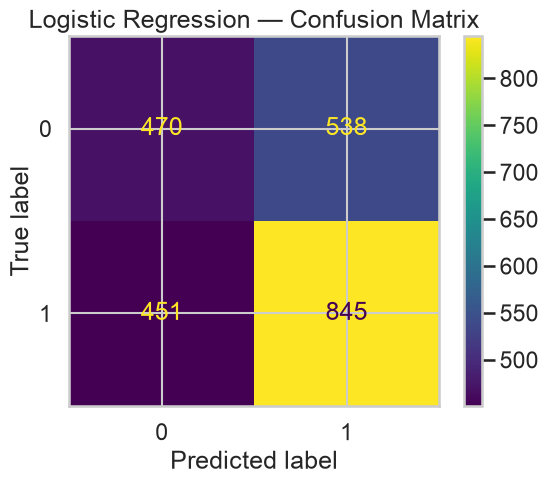

              precision    recall  f1-score   support

           0       0.51      0.47      0.49      1008
           1       0.61      0.65      0.63      1296

    accuracy                           0.57      2304
   macro avg       0.56      0.56      0.56      2304
weighted avg       0.57      0.57      0.57      2304



In [42]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

print(classification_report(y_test, y_pred))

### 12.2 Random Forest

In [43]:
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced",
)
rf.fit(X_train_features, y_train)

y_pred_rf = rf.predict(X_test_features)
y_prob_rf = rf.predict_proba(X_test_features)[:, 1]

results["Random Forest"] = evaluate_predictions(
    "Random Forest", y_test, y_pred_rf, y_prob_rf
)
models_info["Random Forest"] = {
    "model": rf,
    "X_train": X_train_features,
    "X_test": X_test_features,
}

--- Random Forest ---
  Accuracy  : 0.5386
  Precision : 0.6014
  Recall    : 0.5332
  F1        : 0.5652
  ROC-AUC   : 0.5563


### 12.3 SVM

In [44]:
svm = SVC(kernel="rbf", probability=True, random_state=RANDOM_STATE)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

results["SVM"] = evaluate_predictions("SVM", y_test, y_pred_svm, y_prob_svm)
models_info["SVM"] = {
    "model": svm,
    "X_train": X_train_scaled,
    "X_test": X_test_scaled,
}

/Users/parsa/Desktop/projects/github/pxsa/EEG-stress-xai/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


--- SVM ---
  Accuracy  : 0.5443
  Precision : 0.5863
  Recall    : 0.6451
  F1        : 0.6143
  ROC-AUC   : 0.5312


### 12.4 Gradient Boosting

In [45]:
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=RANDOM_STATE,
)
gb.fit(X_train_features, y_train)

y_pred_gb = gb.predict(X_test_features)
y_prob_gb = gb.predict_proba(X_test_features)[:, 1]

results["Gradient Boosting"] = evaluate_predictions(
    "Gradient Boosting", y_test, y_pred_gb, y_prob_gb
)
models_info["Gradient Boosting"] = {
    "model": gb,
    "X_train": X_train_features,
    "X_test": X_test_features,
}

--- Gradient Boosting ---
  Accuracy  : 0.5595
  Precision : 0.6045
  Recall    : 0.6273
  F1        : 0.6157
  ROC-AUC   : 0.5840


### 12.5 XGBoost

In [46]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    eval_metric="logloss",
)
xgb.fit(X_train_features, y_train)

y_pred_xgb = xgb.predict(X_test_features)
y_prob_xgb = xgb.predict_proba(X_test_features)[:, 1]

results["XGBoost"] = evaluate_predictions("XGBoost", y_test, y_pred_xgb, y_prob_xgb)
models_info["XGBoost"] = {
    "model": xgb,
    "X_train": X_train_features,
    "X_test": X_test_features,
}

--- XGBoost ---
  Accuracy  : 0.5577
  Precision : 0.6102
  Recall    : 0.5918
  F1        : 0.6009
  ROC-AUC   : 0.5844


### 12.6 KNN

In [47]:
knn = KNeighborsClassifier(n_neighbors=7, weights="distance")
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

results["KNN"] = evaluate_predictions("KNN", y_test, y_pred_knn, y_prob_knn)
models_info["KNN"] = {
    "model": knn,
    "X_train": X_train_scaled,
    "X_test": X_test_scaled,
}

--- KNN ---
  Accuracy  : 0.5495
  Precision : 0.5895
  Recall    : 0.6559
  F1        : 0.6209
  ROC-AUC   : 0.5496


## 13. Model Comparison

In [48]:
results_df = pd.DataFrame(results).T.sort_values("ROC-AUC", ascending=False)
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
Logistic Regression,0.570747,0.610991,0.652006,0.630832,0.594943
XGBoost,0.557726,0.610183,0.591821,0.600862,0.584403
Gradient Boosting,0.559462,0.604461,0.627315,0.615676,0.583976
Random Forest,0.538628,0.601393,0.533179,0.565235,0.556346
KNN,0.549479,0.589459,0.655864,0.620891,0.549573
SVM,0.544271,0.586255,0.645062,0.614254,0.531174


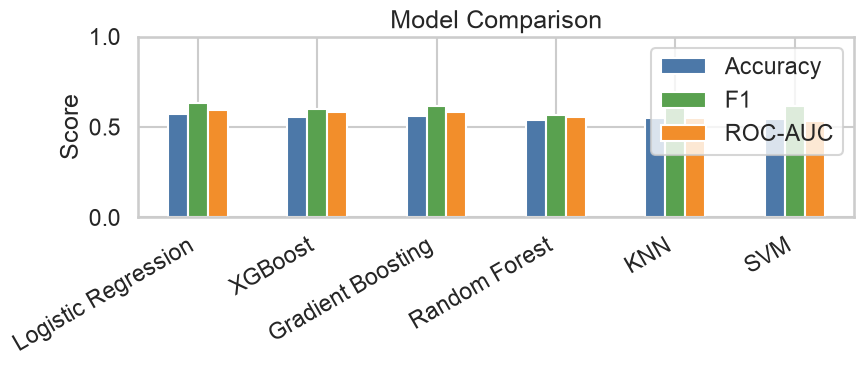

In [49]:
ax = results_df[["Accuracy", "F1", "ROC-AUC"]].plot.bar(figsize=(9, 4), color=["#4C78A8", "#59A14F", "#F28E2B"])
ax.set_ylabel("Score")
ax.set_title("Model Comparison")
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 14. Explainability with SHAP

Band-power features (`channel x band`) are not directly interpretable from raw model
coefficients or impurity-based importances alone — SHAP gives per-prediction,
per-feature contributions that are consistent across model types, so we can:

- see **which channel/band combinations** drive predictions globally,
- inspect **why a single epoch** was classified as stressed / not stressed,
- aggregate importances by **frequency band** and by **channel** for a
  neuroscience-friendly summary.

We explain the best model by ROC-AUC, but the helper below works for any model in
`models_info`.

In [50]:
best_model_name = results_df.index[0]
print("Best model by ROC-AUC:", best_model_name)

TREE_MODELS = {"Random Forest", "Gradient Boosting", "XGBoost"}

Best model by ROC-AUC: Logistic Regression


In [51]:
def compute_shap_values(model_name, background_size=100, sample_size=200, seed=RANDOM_STATE):
    """Compute SHAP values for the positive ("stressed") class.

    Tree-based models use the exact/fast ``TreeExplainer``. Every other model
    falls back to a general, model-agnostic ``Explainer`` wrapped around
    ``predict_proba`` (slower, so both the background set and the explained
    sample are subsampled).

    Returns
    -------
    shap_values : np.ndarray, shape (n_sample, n_features)
    X_sample : np.ndarray, shape (n_sample, n_features)
        The rows that were actually explained.
    base_value : float
        Expected model output over the background distribution.
    """
    info = models_info[model_name]
    model = info["model"]
    X_train_ = info["X_train"]
    X_test_ = info["X_test"]

    rng = np.random.RandomState(seed)
    n_sample = min(sample_size, X_test_.shape[0])
    sample_idx = rng.choice(X_test_.shape[0], size=n_sample, replace=False)
    X_sample = X_test_[sample_idx]

    if model_name in TREE_MODELS:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
        base_value = explainer.expected_value

        # Some SHAP versions return a list [class0, class1] for binary
        # classifiers; others return a single 2D array for the positive class.
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
            base_value = base_value[1]
        elif np.ndim(shap_values) == 3:
            shap_values = shap_values[:, :, 1]
            base_value = base_value[1] if np.ndim(base_value) else base_value
    else:
        background = shap.sample(X_train_, background_size, random_state=seed)
        explainer = shap.Explainer(model.predict_proba, background, feature_names=feature_names)
        explanation = explainer(X_sample)
        shap_values = explanation.values[..., 1]
        base_values = explanation.base_values
        base_value = base_values[..., 1] if np.ndim(base_values) > 0 else base_values
        base_value = np.mean(base_value)

    return np.asarray(shap_values), X_sample, base_value


shap_values, X_shap_sample, shap_base_value = compute_shap_values(best_model_name)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (200, 160)


### 14.1 Global Feature Importance

/var/folders/z1/jg1b__79647749t6sz8jghyw0000gn/T/ipykernel_5415/4086666336.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


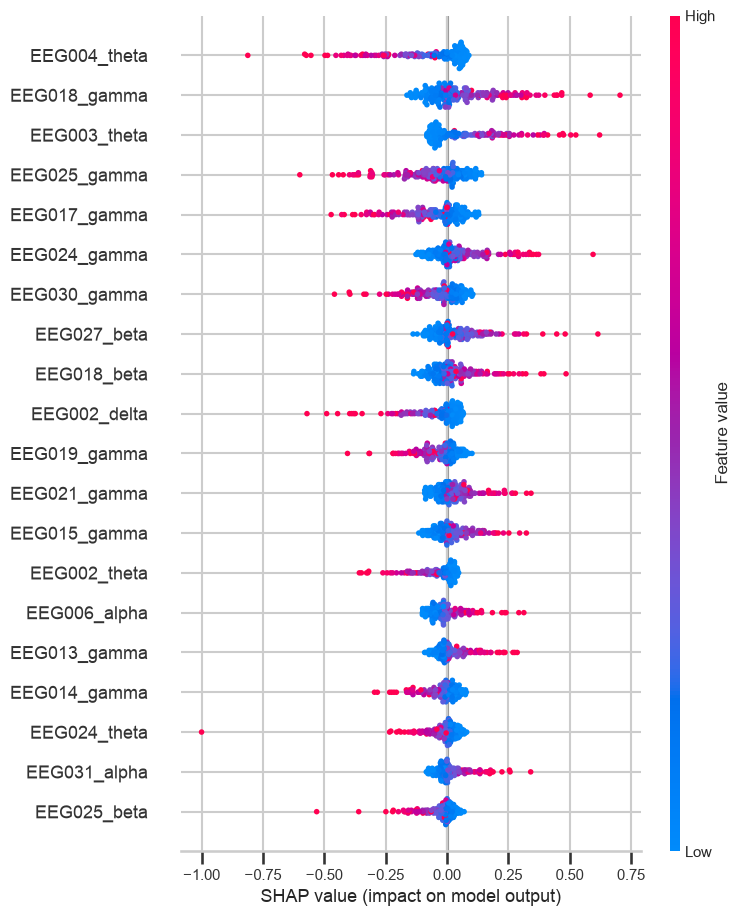

In [52]:
shap.summary_plot(
    shap_values,
    X_shap_sample,
    feature_names=feature_names,
    show=True,
)

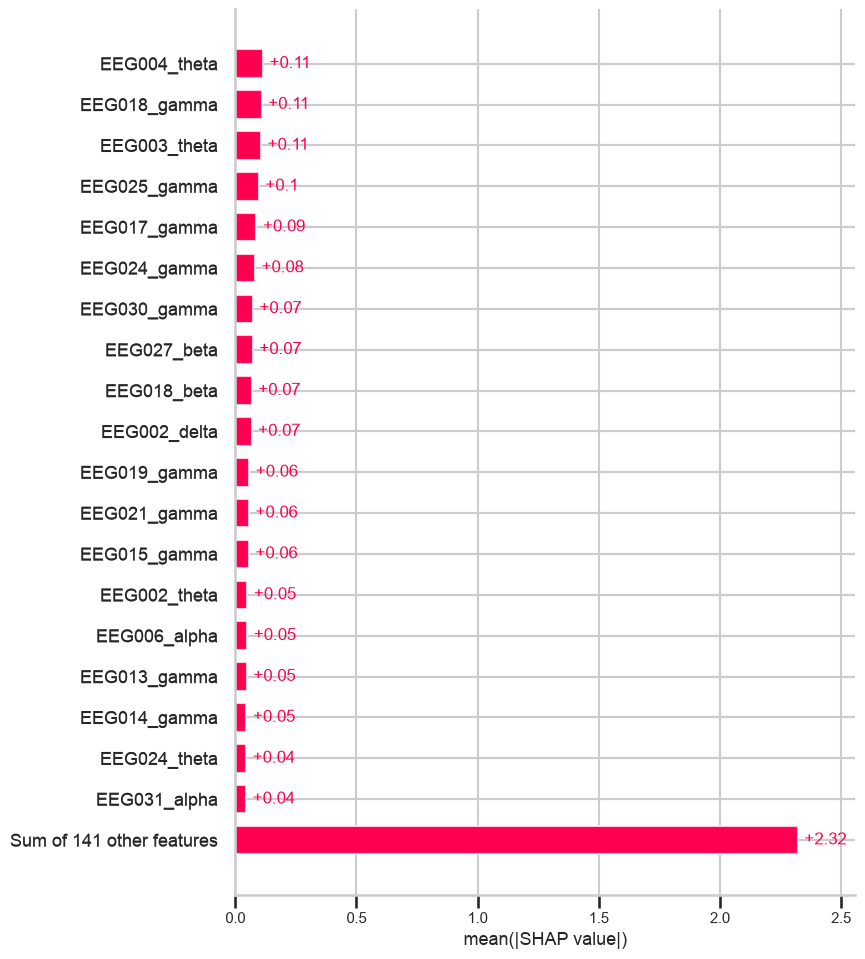

In [53]:
shap_explanation = shap.Explanation(
    values=shap_values,
    base_values=np.full(shap_values.shape[0], shap_base_value),
    data=X_shap_sample,
    feature_names=feature_names,
)

shap.plots.bar(shap_explanation, max_display=20, show=True)

### 14.2 Explaining a Single Prediction

A waterfall plot shows exactly how each feature pushed one specific epoch's
prediction away from the average ("base") model output.

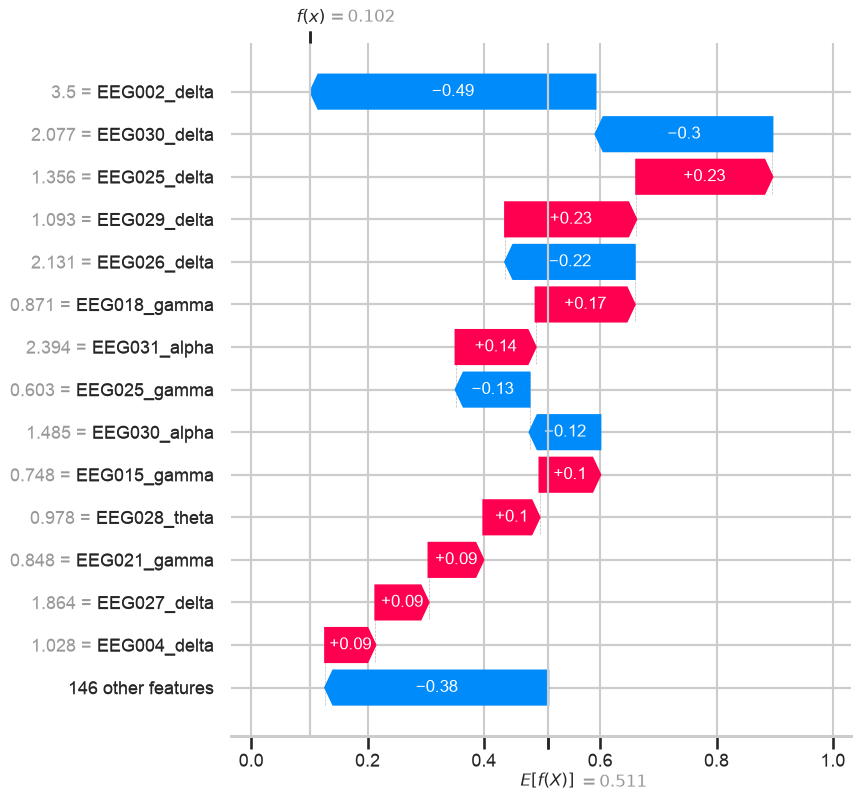

In [54]:
example_idx = 0  # change this to inspect a different test epoch
shap.plots.waterfall(shap_explanation[example_idx], max_display=15, show=True)

### 14.3 Aggregating SHAP by Frequency Band and Channel

There are 160 raw features (32 channels x 5 bands), which is hard to read one-by-one.
Summing `|SHAP value|` within each band / channel gives a much more interpretable,
EEG-relevant summary of what the model is picking up on.

In [55]:
feature_info = pd.DataFrame(
    [name.rsplit("_", 1) for name in feature_names],
    columns=["channel", "band"],
)
feature_info["mean_abs_shap"] = np.abs(shap_values).mean(axis=0)

band_importance = (
    feature_info.groupby("band")["mean_abs_shap"].sum().sort_values(ascending=False)
)
channel_importance = (
    feature_info.groupby("channel")["mean_abs_shap"].sum().sort_values(ascending=False)
)

print("Importance by frequency band:")
print(band_importance)
print("\nTop 10 channels by importance:")
print(channel_importance.head(10))

Importance by frequency band:
band
gamma    1.230723
beta     0.794618
theta    0.750043
alpha    0.452616
delta    0.409246
Name: mean_abs_shap, dtype: float64

Top 10 channels by importance:
channel
EEG004    0.238326
EEG018    0.218505
EEG025    0.203040
EEG003    0.202792
EEG024    0.181983
EEG030    0.177523
EEG017    0.147780
EEG027    0.146026
EEG006    0.142912
EEG002    0.141776
Name: mean_abs_shap, dtype: float64


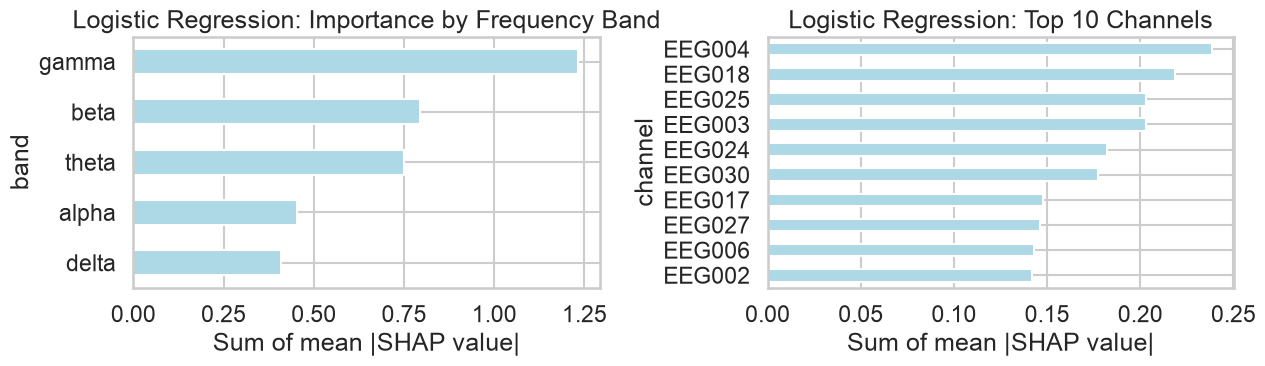

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

band_importance.sort_values().plot.barh(ax=axes[0], color='lightblue')
axes[0].set_title(f"{best_model_name}: Importance by Frequency Band")
axes[0].set_xlabel("Sum of mean |SHAP value|")

channel_importance.head(10).sort_values().plot.barh(ax=axes[1], color='lightblue')
axes[1].set_title(f"{best_model_name}: Top 10 Channels")
axes[1].set_xlabel("Sum of mean |SHAP value|")

plt.tight_layout()
plt.show()

### 14.4 Dependence Plot for the Top Feature

Shows how the value of the single most important feature relates to its impact on the
model's output, and whether that relationship is modulated by another feature
(SHAP picks the strongest interacting feature automatically).

Top feature: EEG004_theta


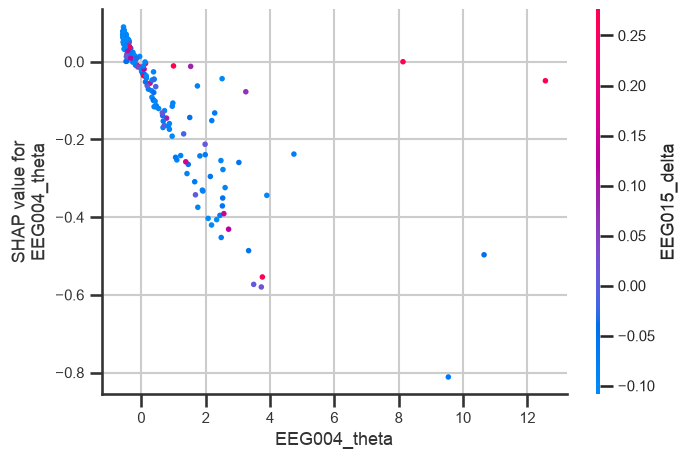

In [59]:
top_feature_idx = int(np.argmax(np.abs(shap_values).mean(axis=0)))
top_feature_name = feature_names[top_feature_idx]
print("Top feature:", top_feature_name)

shap.dependence_plot(
    top_feature_idx,
    shap_values,
    X_shap_sample,
    feature_names=feature_names,
    show=True,
)